# 🎯 Attendance System - Preprocessing & Face Detection Pipeline

This notebook contains the specialized image preprocessing workflow for your facial recognition attendance system. It includes:

1. **Image Conversion** - Convert HEIC files and standardize formats
2. **Grayscale & CLAHE Preprocessing** - Apply grayscale conversion and CLAHE enhancement
3. **Face Detection & ROI Extraction** - Detect faces and extract ROI with padding
4. **Post-Processing** - Apply grayscale + CLAHE on cropped faces and resize to 128x128
5. **Data Augmentation (Member 3)** - Expand dataset using Albumentations + illumination evaluation
   - 5a: Raw image augmentation (for preview & illumination evaluation)
   - 5b: Face crop augmentation (training-ready augmented data)
6. **Training Data Preparation (Member 3)** - Load & split augmented face crops (80/20)
7. **LBPH Model Training & Evaluation (Member 3)** - Train LBPH recognizer, evaluate accuracy, compare with/without augmentation

## 📁 Expected Folder Structure
```
data/
├── raw/                     # Original images (input)
│   └── [person_name]/
├── augmented/               # Augmented face crops (training-ready)
│   └── [person_name]/
├── preprocessed/            # Grayscale + CLAHE processed images (Member 1 output)
│   └── [person_name]/
├── converted/               # Standardized JPG images
├── faces_detected/          # Extracted face ROIs (128x128)
├── final_processed/         # Post-processed face ROIs (Member 2 input)
└── preview/                 # Preview & evaluation results
    ├── augmentation_samples/
    └── evaluation_results/
models/
├── lbph_model.yml           # Trained LBPH face recognizer
└── label_map.txt            # Person name → label ID mapping
```


In [5]:
# Import all required libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import face_recognition
import time
import random
from pathlib import Path
from PIL import Image, ImageEnhance, ImageOps
import dlib

# For HEIC conversion
try:
    from pillow_heif import register_heif_opener
    register_heif_opener()
    HAS_HEIF_SUPPORT = True
    print("✅ HEIC support available")
except ImportError:
    HAS_HEIF_SUPPORT = False
    print("⚠️  HEIC support not available. Install pillow-heif if needed.")

# For advanced augmentation
try:
    import albumentations as A
    HAS_ALBUMENTATIONS = True
    print("✅ Advanced augmentation available")
except ImportError:
    HAS_ALBUMENTATIONS = False
    print("⚠️  Advanced augmentation not available. Install albumentations if needed.")

try:
    import dlib
    print("✅ dlib support available")
except ImportError:
    print("⚠️  dlib support not available. Install dlib if needed.")

print("📦 Core libraries loaded successfully!")

✅ HEIC support available
✅ Advanced augmentation available
✅ dlib support available
📦 Core libraries loaded successfully!


# 🔧 Configuration Settings

Adjust these settings based on your needs:

In [6]:
# === CONFIGURATION SETTINGS ===

# File paths (relative to this notebook)
DATA_FOLDER = os.path.join("..", "data")
RAW_FOLDER = os.path.join(DATA_FOLDER, "raw")
AUGMENTED_FOLDER = os.path.join(DATA_FOLDER, "augmented")
PREPROCESSED_FOLDER = os.path.join(DATA_FOLDER, "preprocessed")
CONVERTED_FOLDER = os.path.join(DATA_FOLDER, "converted")
FACES_DETECTED_FOLDER = os.path.join(DATA_FOLDER, "faces_detected")
FINAL_PROCESSED_FOLDER = os.path.join(DATA_FOLDER, "final_processed")
PREVIEW_FOLDER = os.path.join(DATA_FOLDER, "preview")

# Models folder (at project root level, not inside data/)
MODELS_FOLDER = os.path.join("..", "models")

# Preprocessing settings
FACE_PADDING_RATIO = 0.2  # 20% padding around detected faces
OUTPUT_SIZE = (128, 128)  # Final size for preprocessed face images
CLAHE_CLIP_LIMIT = 2.0  # CLAHE clip limit for contrast enhancement
CLAHE_GRID_SIZE = (8, 8)  # CLAHE grid size for local enhancement
BLUR_THRESHOLD = 40       # Laplacian variance threshold — images below this are filtered as blur

# Detection settings
DETECTION_SCALE_FACTOR = 0.25  # Scale factor for faster detection (1/4 size)
DETECTION_MODEL = "hog"  # Face detection model: 'hog' for speed, 'cnn' for accuracy

# Image conversion settings
IMAGE_QUALITY = 95  # JPG quality (1-100)
MAX_IMAGE_SIZE = (1024, 1024)  # Max size for converted images

# Display settings
PREVIEW_GRID_COLS = 4  # Columns in preview grids
FIGURE_SIZE = (15, 10)  # Default matplotlib figure size

print("⚙️ Configuration loaded!")
print(f"📁 Data folder:          {DATA_FOLDER}")
print(f"📁 Raw folder:           {RAW_FOLDER}")
print(f"📁 Augmented folder:     {AUGMENTED_FOLDER}")
print(f"📁 Preprocessed folder:  {PREPROCESSED_FOLDER}")
print(f"📁 Faces detected folder:{FACES_DETECTED_FOLDER}")
print(f"📁 Final processed:      {FINAL_PROCESSED_FOLDER}")
print(f"📁 Preview folder:       {PREVIEW_FOLDER}")
print(f"📁 Models folder:        {MODELS_FOLDER}")
print(f"🖼️  Output size:          {OUTPUT_SIZE}")
print(f"🔍 Detection model:      {DETECTION_MODEL}")
print(f"📊 CLAHE settings:       clip_limit={CLAHE_CLIP_LIMIT}, grid_size={CLAHE_GRID_SIZE}")
print(f"🔍 Blur threshold:       {BLUR_THRESHOLD} (Laplacian variance)")


⚙️ Configuration loaded!
📁 Data folder:          ..\data
📁 Raw folder:           ..\data\raw
📁 Augmented folder:     ..\data\augmented
📁 Preprocessed folder:  ..\data\preprocessed
📁 Faces detected folder:..\data\faces_detected
📁 Final processed:      ..\data\final_processed
📁 Preview folder:       ..\data\preview
📁 Models folder:        ..\models
🖼️  Output size:          (128, 128)
🔍 Detection model:      hog
📊 CLAHE settings:       clip_limit=2.0, grid_size=(8, 8)
🔍 Blur threshold:       40 (Laplacian variance)


In [7]:
# === CREATE DATASET FOLDERS ===
# Run this once to set up the raw input folder structure.
# Pipeline output folders (converted, preprocessed, faces_detected,
# final_processed, augmented) are created automatically when each step runs.

people = [
    "zi_herng",
    "yong_kang",
    "yoke_hong",
    "xu_sheng",
    "xiang_yue",
    "wee_xuan",
    "Dr.Nurul",
    "shuang_quan",
    "qi_xuan",
    "marion",
    "kang_kai",
    "harry",
    "han_soon",
    "daniel",
    "dylan",
    "chillien",
    "chern_tak",
    "benjamin",
]

print("📁 Creating raw input folder structure...")
print("=" * 45)
print(f"\n  📂 data/raw/")

for person in people:
    person_path = os.path.join(RAW_FOLDER, person)
    os.makedirs(person_path, exist_ok=True)
    print(f"    ✅ {person}/")

print("\n✨ Done! Raw folders created.")
print(f"\n📸 Next step: Add each person's photos into their raw/ folder")
print(f"   Supported formats: .jpg, .jpeg, .png, .heic")
print(f"\n📂 Raw folder path: {os.path.abspath(RAW_FOLDER)}")


📁 Creating raw input folder structure...

  📂 data/raw/
    ✅ zi_herng/
    ✅ yong_kang/
    ✅ yoke_hong/
    ✅ xu_sheng/
    ✅ xiang_yue/
    ✅ wee_xuan/
    ✅ Dr.Nurul/
    ✅ shuang_quan/
    ✅ qi_xuan/
    ✅ marion/
    ✅ kang_kai/
    ✅ harry/
    ✅ han_soon/
    ✅ daniel/
    ✅ dylan/
    ✅ chillien/
    ✅ chern_tak/
    ✅ benjamin/

✨ Done! Raw folders created.

📸 Next step: Add each person's photos into their raw/ folder
   Supported formats: .jpg, .jpeg, .png, .heic

📂 Raw folder path: c:\Users\jaft9\School\AttSystem\data\raw


# 📊 Dataset Analysis

Let's first analyze your current dataset:

In [8]:
def analyze_dataset():
    """Analyze the current raw dataset structure and contents."""

    if not os.path.exists(RAW_FOLDER):
        print(f"❌ Raw folder not found: {RAW_FOLDER}")
        return False

    print("🔍 DATASET ANALYSIS (Raw Images)")
    print("=" * 50)

    person_dirs = [f for f in os.listdir(RAW_FOLDER)
                   if os.path.isdir(os.path.join(RAW_FOLDER, f))]

    if not person_dirs:
        print(f"❌ No person folders found in {RAW_FOLDER}")
        print("   Create a subfolder per person and add their photos.")
        return False

    total_images = 0
    format_stats = {}
    person_stats = {}

    print(f"📁 Found {len(person_dirs)} people in data/raw/:\n")

    for person in sorted(person_dirs):
        person_path = os.path.join(RAW_FOLDER, person)
        image_files = [f for f in os.listdir(person_path)
                       if os.path.isfile(os.path.join(person_path, f)) and
                       Path(f).suffix.lower() in {'.jpg', '.jpeg', '.png', '.heic'}]

        person_stats[person] = len(image_files)
        total_images += len(image_files)

        for img in image_files:
            ext = Path(img).suffix.lower()
            format_stats[ext] = format_stats.get(ext, 0) + 1

        flag = "✅" if len(image_files) >= 5 else ("⚠️" if len(image_files) > 0 else "❌")
        print(f"  {flag} {person}: {len(image_files)} images")

    print(f"\n📊 SUMMARY:")
    print(f"  • Total people:        {len(person_dirs)}")
    print(f"  • Total images:        {total_images}")
    if person_dirs:
        print(f"  • Avg per person:      {total_images / len(person_dirs):.1f}")
        min_person = min(person_stats, key=person_stats.get)
        max_person = max(person_stats, key=person_stats.get)
        print(f"  • Min: {person_stats[min_person]} ({min_person})")
        print(f"  • Max: {person_stats[max_person]} ({max_person})")

    print(f"\n📸 IMAGE FORMATS:")
    for ext, count in sorted(format_stats.items()):
        pct = count / total_images * 100 if total_images > 0 else 0
        print(f"  • {ext}: {count} ({pct:.1f}%)")

    print(f"\n📂 PROCESSING FOLDERS STATUS:")
    pipeline_folders = [
        ('converted',       CONVERTED_FOLDER),
        ('preprocessed',    PREPROCESSED_FOLDER),
        ('faces_detected',  FACES_DETECTED_FOLDER),
        ('final_processed', FINAL_PROCESSED_FOLDER),
        ('augmented',       AUGMENTED_FOLDER),
    ]
    for name, path in pipeline_folders:
        if os.path.exists(path):
            count = sum(
                len([f for f in os.listdir(os.path.join(path, p))
                     if Path(f).suffix.lower() in {'.jpg', '.jpeg', '.png'}])
                for p in os.listdir(path)
                if os.path.isdir(os.path.join(path, p))
            )
            print(f"  ✅ {name}: {count} files")
        else:
            print(f"  ❌ {name}: not created yet")

    people_with_few = [p for p, c in person_stats.items() if c < 5]
    if people_with_few:
        print(f"\n⚠️  People with fewer than 5 images (add more photos):")
        for p in people_with_few:
            print(f"     • {p}: {person_stats[p]} image(s)")

    return True

# Run the analysis
analyze_dataset()


🔍 DATASET ANALYSIS (Raw Images)
📁 Found 18 people in data/raw/:

  ✅ Dr.Nurul: 11 images
  ✅ benjamin: 31 images
  ✅ chern_tak: 36 images
  ✅ chillien: 6 images
  ✅ daniel: 54 images
  ✅ dylan: 40 images
  ✅ han_soon: 11 images
  ✅ harry: 23 images
  ✅ kang_kai: 6 images
  ⚠️ marion: 2 images
  ⚠️ qi_xuan: 2 images
  ✅ shuang_quan: 54 images
  ✅ wee_xuan: 16 images
  ✅ xiang_yue: 24 images
  ✅ xu_sheng: 23 images
  ✅ yoke_hong: 35 images
  ⚠️ yong_kang: 3 images
  ⚠️ zi_herng: 1 images

📊 SUMMARY:
  • Total people:        18
  • Total images:        378
  • Avg per person:      21.0
  • Min: 1 (zi_herng)
  • Max: 54 (daniel)

📸 IMAGE FORMATS:
  • .heic: 269 (71.2%)
  • .jpeg: 28 (7.4%)
  • .jpg: 72 (19.0%)
  • .png: 9 (2.4%)

📂 PROCESSING FOLDERS STATUS:
  ✅ converted: 161 files
  ✅ preprocessed: 322 files
  ✅ faces_detected: 228 files
  ✅ final_processed: 228 files
  ✅ augmented: 3200 files

⚠️  People with fewer than 5 images (add more photos):
     • marion: 2 image(s)
     • qi_xua

True

# 🔄 Step 1: Image Conversion & Standardization

Convert HEIC files to JPG and standardize all images:

In [47]:
def convert_heic_to_jpg(input_path, output_path, quality=95):
    """Convert HEIC file to JPG"""
    if not HAS_HEIF_SUPPORT:
        print(f"⚠️ HEIC support not available. Skipping {input_path}")
        return False
    
    try:
        with Image.open(input_path) as image:
            if image.mode != 'RGB':
                image = image.convert('RGB')
            image.save(output_path, 'JPEG', quality=quality, optimize=True)
            return True
    except Exception as e:
        print(f"❌ Error converting {input_path}: {e}")
        return False

def standardize_image(input_path, output_path, target_size=MAX_IMAGE_SIZE, quality=IMAGE_QUALITY):
    """Standardize image size and format"""
    try:
        with Image.open(input_path) as image:
            if image.mode != 'RGB':
                image = image.convert('RGB')
            
            # Resize while maintaining aspect ratio
            image = ImageOps.fit(image, target_size, Image.Resampling.LANCZOS)
            image.save(output_path, 'JPEG', quality=quality, optimize=True)
            return True
    except Exception as e:
        print(f"❌ Error standardizing {input_path}: {e}")
        return False

def is_blurry(image, threshold=None):
    """
    Detect if an image is blurry using Laplacian variance.
    The higher the variance, the sharper the image.

    Args:
        image    : BGR numpy array (from cv2.imread) or a file path string
        threshold: Images whose Laplacian variance is below this value are
                   considered blurry. Default: BLUR_THRESHOLD from config.
    Returns:
        (is_blurry: bool, score: float)
    """
    if threshold is None:
        threshold = BLUR_THRESHOLD
    if isinstance(image, str):
        img = cv2.imread(image)
        if img is None:
            return True, 0.0
    else:
        img = image
    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img
    score = cv2.Laplacian(gray, cv2.CV_64F).var()
    return score < threshold, round(score, 1)

def convert_all_images():
    """Convert and standardize all images from raw/, skipping blurry ones."""
    print("🔄 STARTING IMAGE CONVERSION")
    print("=" * 50)
    print(f"🔍 Blur filter: ON  (threshold={BLUR_THRESHOLD} — lower score = blurrier)")

    os.makedirs(CONVERTED_FOLDER, exist_ok=True)

    if not os.path.exists(RAW_FOLDER):
        print(f"❌ Raw folder not found: {RAW_FOLDER}")
        return 0, 0, 0

    person_dirs = [f for f in os.listdir(RAW_FOLDER)
                   if os.path.isdir(os.path.join(RAW_FOLDER, f))]

    if not person_dirs:
        print(f"❌ No person folders found in {RAW_FOLDER}")
        print("   Create a subfolder per person and add their photos.")
        return 0, 0, 0

    total_converted = 0
    total_failed    = 0
    total_blurry    = 0

    for person in person_dirs:
        person_input_path  = os.path.join(RAW_FOLDER, person)
        person_output_path = os.path.join(CONVERTED_FOLDER, person)
        os.makedirs(person_output_path, exist_ok=True)

        image_extensions = {'.jpg', '.jpeg', '.png', '.heic', '.JPG', '.JPEG', '.PNG', '.HEIC'}
        image_files = [f for f in os.listdir(person_input_path)
                      if Path(f).suffix in image_extensions]

        print(f"\n👤 Processing {person} ({len(image_files)} images):")

        output_index = 1
        for filename in image_files:
            input_file = os.path.join(person_input_path, filename)
            is_heic    = Path(filename).suffix.lower() == '.heic'

            # --- Blur detection for non-HEIC (cv2 can read these directly) ---
            if not is_heic:
                img_check = cv2.imread(input_file)
                if img_check is not None:
                    blurry, blur_score = is_blurry(img_check)
                    if blurry:
                        print(f"  ⚠️ Skipped (blurry, score={blur_score:.1f}): {filename}")
                        total_blurry += 1
                        continue

            output_filename = f"{person}_{output_index:03d}.jpg"
            output_file     = os.path.join(person_output_path, output_filename)

            # --- Convert ---
            if is_heic:
                success = convert_heic_to_jpg(input_file, output_file, IMAGE_QUALITY)
                # For HEIC: check blur on the converted output
                if success:
                    converted_img = cv2.imread(output_file)
                    if converted_img is not None:
                        blurry, blur_score = is_blurry(converted_img)
                        if blurry:
                            os.remove(output_file)
                            print(f"  ⚠️ Skipped (blurry HEIC, score={blur_score:.1f}): {filename}")
                            total_blurry += 1
                            continue
            else:
                success = standardize_image(input_file, output_file)

            if success:
                print(f"  ✅ {filename} → {output_filename}")
                total_converted += 1
                output_index    += 1
            else:
                print(f"  ❌ Failed: {filename}")
                total_failed += 1

    print(f"\n✨ CONVERSION COMPLETE!")
    print(f"  ✅ Converted:        {total_converted}")
    print(f"  ⚠️ Blurry (skipped): {total_blurry}")
    print(f"  ❌ Failed:           {total_failed}")
    print(f"  📁 Output: {CONVERTED_FOLDER}")

    return total_converted, total_failed, total_blurry

# Run conversion
conversion_stats = convert_all_images()


🔄 STARTING IMAGE CONVERSION
🔍 Blur filter: ON  (threshold=40 — lower score = blurrier)

👤 Processing benjamin (41 images):
  ⚠️ Skipped (blurry, score=18.2): IMG_1924.JPG
  ⚠️ Skipped (blurry, score=18.3): IMG_1925.JPG
  ⚠️ Skipped (blurry, score=18.3): IMG_1926.JPG
  ⚠️ Skipped (blurry, score=10.2): IMG_1929.JPG
  ⚠️ Skipped (blurry, score=11.9): IMG_1930.JPG
  ⚠️ Skipped (blurry, score=12.0): IMG_1931.JPG
  ⚠️ Skipped (blurry, score=11.3): IMG_1932.JPG
  ⚠️ Skipped (blurry, score=11.2): IMG_1933.JPG
  ⚠️ Skipped (blurry, score=11.8): IMG_1934.JPG
  ✅ IMG_5267.HEIC → benjamin_001.jpg
  ⚠️ Skipped (blurry HEIC, score=38.1): IMG_5268.HEIC
  ⚠️ Skipped (blurry HEIC, score=27.4): IMG_5269.HEIC
  ⚠️ Skipped (blurry HEIC, score=23.0): IMG_5270.HEIC
  ✅ IMG_5271.HEIC → benjamin_002.jpg
  ✅ IMG_5272.HEIC → benjamin_003.jpg
  ✅ IMG_5273.HEIC → benjamin_004.jpg
  ✅ IMG_5274.HEIC → benjamin_005.jpg
  ⚠️ Skipped (blurry HEIC, score=18.2): IMG_5275.HEIC
  ⚠️ Skipped (blurry HEIC, score=23.1): IMG_

# 🔄 Step 2: Grayscale & CLAHE Preprocessing

Apply grayscale conversion and CLAHE enhancement to all converted images for better face detection:

In [48]:
class ImagePreprocessor:
    def __init__(self, clahe_clip_limit=CLAHE_CLIP_LIMIT, clahe_grid_size=CLAHE_GRID_SIZE):
        """Initialize preprocessor with CLAHE settings"""
        self.clahe = cv2.createCLAHE(clipLimit=clahe_clip_limit, tileGridSize=clahe_grid_size)
        print(f"✅ Image preprocessor initialized")
        print(f"   • CLAHE clip limit: {clahe_clip_limit}")
        print(f"   • CLAHE grid size: {clahe_grid_size}")
    
    def preprocess_image(self, image):
        """Apply grayscale conversion and CLAHE enhancement"""
        # Convert to grayscale
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image
        
        # Apply CLAHE enhancement
        enhanced = self.clahe.apply(gray)
        
        return gray, enhanced
    
    def preprocess_folder(self, input_folder, output_folder):
        """Process all images in a folder with grayscale + CLAHE"""
        # Create output folder
        os.makedirs(output_folder, exist_ok=True)
        
        # Get person folders
        person_folders = [f for f in os.listdir(input_folder) 
                         if os.path.isdir(os.path.join(input_folder, f))]
        
        total_processed = 0
        total_failed = 0
        
        for person in person_folders:
            person_input_path = os.path.join(input_folder, person)
            person_output_path = os.path.join(output_folder, person)
            
            # Get image files
            image_files = [f for f in os.listdir(person_input_path) if f.lower().endswith('.jpg')]
            
            # Skip folders with no images — don't create empty output dirs
            if not image_files:
                print(f"  ⚠️ No images found for {person} — skipped")
                continue
            
            os.makedirs(person_output_path, exist_ok=True)
            
            print(f"\n👤 Preprocessing {person} ({len(image_files)} images):")
            
            for image_file in image_files:
                input_path = os.path.join(person_input_path, image_file)
                image = cv2.imread(input_path)
                
                if image is None:
                    print(f"  ❌ Failed to read: {image_file}")
                    total_failed += 1
                    continue
                
                # Apply preprocessing
                gray, enhanced = self.preprocess_image(image)
                
                # Save both versions
                base_name = Path(image_file).stem
                
                # Save grayscale version
                gray_path = os.path.join(person_output_path, f"{base_name}_gray.jpg")
                cv2.imwrite(gray_path, gray)
                
                # Save CLAHE enhanced version
                enhanced_path = os.path.join(person_output_path, f"{base_name}_clahe.jpg")
                cv2.imwrite(enhanced_path, enhanced)
                
                total_processed += 1
                print(f"  ✅ {image_file} → gray + CLAHE versions")
        
        print(f"\n✨ PREPROCESSING COMPLETE!")
        print(f"  ✅ Processed: {total_processed}")
        print(f"  ❌ Failed: {total_failed}")
        print(f"  📁 Output: {output_folder}")
        
        return total_processed, total_failed

# Initialize preprocessor
preprocessor = ImagePreprocessor()
print("🔄 Image preprocessor ready!")


✅ Image preprocessor initialized
   • CLAHE clip limit: 2.0
   • CLAHE grid size: (8, 8)
🔄 Image preprocessor ready!
✅ Image preprocessor initialized
   • CLAHE clip limit: 2.0
   • CLAHE grid size: (8, 8)
🔄 Image preprocessor ready!


In [49]:
def run_preprocessing():
    """Apply grayscale + CLAHE preprocessing to converted images"""
    print("🔄 STARTING PREPROCESSING")  
    print("=" * 50)
    
    if not os.path.exists(CONVERTED_FOLDER):
        print("❌ Converted folder not found! Please run image conversion first.")
        return
    
    # Run preprocessing
    stats = preprocessor.preprocess_folder(CONVERTED_FOLDER, PREPROCESSED_FOLDER)
    
    print("\n📊 PREPROCESSING SUMMARY:")
    print(f"Images processed: {stats[0]}")
    print(f"Failed: {stats[1]}")
    print(f"📁 Output: {PREPROCESSED_FOLDER}")
    
    return stats

# Run preprocessing
preprocessing_stats = run_preprocessing()

🔄 STARTING PREPROCESSING
🔄 STARTING PREPROCESSING

👤 Preprocessing benjamin (8 images):
  ✅ benjamin_001.jpg → gray + CLAHE versions
  ✅ benjamin_002.jpg → gray + CLAHE versions
  ✅ benjamin_003.jpg → gray + CLAHE versions
  ✅ benjamin_004.jpg → gray + CLAHE versions
  ✅ benjamin_005.jpg → gray + CLAHE versions
  ✅ benjamin_006.jpg → gray + CLAHE versions
  ✅ benjamin_007.jpg → gray + CLAHE versions
  ✅ benjamin_008.jpg → gray + CLAHE versions

👤 Preprocessing chern_tak (17 images):
  ✅ chern_tak_001.jpg → gray + CLAHE versions
  ✅ chern_tak_002.jpg → gray + CLAHE versions
  ✅ chern_tak_003.jpg → gray + CLAHE versions
  ✅ chern_tak_004.jpg → gray + CLAHE versions
  ✅ chern_tak_005.jpg → gray + CLAHE versions
  ✅ chern_tak_006.jpg → gray + CLAHE versions
  ✅ chern_tak_007.jpg → gray + CLAHE versions
  ✅ chern_tak_008.jpg → gray + CLAHE versions
  ✅ chern_tak_009.jpg → gray + CLAHE versions
  ✅ chern_tak_010.jpg → gray + CLAHE versions
  ✅ chern_tak_011.jpg → gray + CLAHE versions
  ✅ ch

# 👁️ Step 3: Face Detection & ROI Extraction

Detect faces in preprocessed images and extract regions of interest with padding:

In [50]:
class FaceROIExtractor:
    def __init__(self, padding_ratio=FACE_PADDING_RATIO, target_size=OUTPUT_SIZE):
        """Initialize face ROI extractor for preprocessed images"""
        self.padding_ratio = padding_ratio
        self.target_size = target_size
        
        # For OpenCV cascade classifier
        self.face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
        
        print(f"✅ Face ROI extractor initialized")
        print(f"   • Padding ratio: {padding_ratio}")
        print(f"   • Target output size: {target_size}")
    
    def detect_faces_opencv(self, image):
        """Detect faces using OpenCV cascade classifier"""
        faces = self.face_cascade.detectMultiScale(
            image,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(30, 30)
        )
        return [(x, y, w, h) for (x, y, w, h) in faces]
    
    def detect_faces_dlib(self, image):
        """Detect faces using face_recognition library (HOG)"""
        try:
            # face_recognition expects RGB format
            if len(image.shape) == 3:
                rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            else:
                rgb_image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
            
            # Get face locations
            face_locations = face_recognition.face_locations(rgb_image, model="hog")
            
            # Convert to (x, y, w, h) format
            faces = []
            for (top, right, bottom, left) in face_locations:
                x, y, w, h = left, top, right - left, bottom - top
                faces.append((x, y, w, h))
            
            return faces
        except Exception as e:
            print(f"  ⚠️ HOG detection failed, falling back to OpenCV: {e}")
            return self.detect_faces_opencv(image)
    
    def extract_roi_with_padding(self, image, x, y, w, h):
        """Extract face ROI with padding"""
        # Calculate padding
        pad_w = int(w * self.padding_ratio)
        pad_h = int(h * self.padding_ratio)
        
        # Calculate padded coordinates
        x1 = max(0, x - pad_w)
        y1 = max(0, y - pad_h)
        x2 = min(image.shape[1], x + w + pad_w)
        y2 = min(image.shape[0], y + h + pad_h)
        
        # Extract ROI
        roi = image[y1:y2, x1:x2]
        
        return roi, (x1, y1, x2, y2)
    
    def process_preprocessed_folder(self, input_folder, output_folder):
        """Process preprocessed images and extract face ROIs"""
        os.makedirs(output_folder, exist_ok=True)
        
        # Get person folders  
        person_folders = [f for f in os.listdir(input_folder) 
                         if os.path.isdir(os.path.join(input_folder, f))]
        
        total_processed = 0
        total_faces = 0
        total_failed = 0
        
        for person in person_folders:
            person_input_path = os.path.join(input_folder, person)
            person_output_path = os.path.join(output_folder, person)
            
            # Get preprocessed images (both gray and clahe)
            image_files = [f for f in os.listdir(person_input_path) 
                          if f.lower().endswith('.jpg') and ('_clahe.jpg' in f or '_gray.jpg' in f)]
            
            # Skip folders with no valid images — don't create empty output dirs
            if not image_files:
                print(f"  ⚠️ No preprocessed images found for {person} — skipped")
                continue
            
            os.makedirs(person_output_path, exist_ok=True)
            
            print(f"\n👤 Processing {person} ({len(image_files)} preprocessed images):")
            
            for image_file in image_files:
                input_path = os.path.join(person_input_path, image_file)
                image = cv2.imread(input_path)
                
                if image is None:
                    print(f"  ❌ Failed to read: {image_file}")
                    total_failed += 1
                    continue
                
                # Convert to grayscale for face detection if needed
                if len(image.shape) == 3:
                    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                else:
                    gray = image
                
                # Detect faces
                faces = self.detect_faces_dlib(gray)
                
                if not faces:
                    print(f"  ❌ No face detected: {image_file}")
                    total_failed += 1
                    continue
                
                # Process each detected face
                base_name = Path(image_file).stem
                for i, (x, y, w, h) in enumerate(faces):
                    # Extract ROI with padding
                    roi, coords = self.extract_roi_with_padding(gray, x, y, w, h)
                    
                    # Resize to target size
                    resized_roi = cv2.resize(roi, self.target_size)
                    
                    # Save face ROI
                    face_filename = f"{base_name}_face_{i}.jpg"
                    face_path = os.path.join(person_output_path, face_filename)
                    cv2.imwrite(face_path, resized_roi, [cv2.IMWRITE_JPEG_QUALITY, IMAGE_QUALITY])
                    
                    total_faces += 1
                    print(f"  ✅ {image_file} → face_{i} ({self.target_size}px)")
                
                total_processed += 1
        
        print(f"\n✨ FACE ROI EXTRACTION COMPLETE!")
        print(f"  ✅ Images processed: {total_processed}")
        print(f"  👤 Faces extracted: {total_faces}")
        print(f"  ❌ Failed: {total_failed}")
        print(f"  📁 Output: {output_folder}")
        
        return total_processed, total_faces, total_failed

# Initialize face ROI extractor
roi_extractor = FaceROIExtractor()
print("👁️ Face ROI extractor ready!")


✅ Face ROI extractor initialized
   • Padding ratio: 0.2
   • Target output size: (128, 128)
👁️ Face ROI extractor ready!


In [51]:
def extract_faces_from_preprocessed():
    """Extract face ROIs from preprocessed images"""
    print("👁️ STARTING FACE ROI EXTRACTION")
    print("=" * 50)
    
    if not os.path.exists(PREPROCESSED_FOLDER):
        print("❌ Preprocessed folder not found! Please run preprocessing first.")
        return
    
    # Extract faces from preprocessed images
    stats = roi_extractor.process_preprocessed_folder(PREPROCESSED_FOLDER, FACES_DETECTED_FOLDER)
    
    print("\n📊 EXTRACTION SUMMARY:")
    print(f"Images processed: {stats[0]}")
    print(f"Faces extracted: {stats[1]}")
    print(f"Failed: {stats[2]}")
    
    return stats

# Run face ROI extraction
face_roi_stats = extract_faces_from_preprocessed()

👁️ STARTING FACE ROI EXTRACTION

👤 Processing benjamin (16 preprocessed images):
  ✅ benjamin_001_clahe.jpg → face_0 ((128, 128)px)
  ✅ benjamin_001_gray.jpg → face_0 ((128, 128)px)
  ✅ benjamin_002_clahe.jpg → face_0 ((128, 128)px)
  ✅ benjamin_002_gray.jpg → face_0 ((128, 128)px)
  ✅ benjamin_003_clahe.jpg → face_0 ((128, 128)px)
  ✅ benjamin_003_gray.jpg → face_0 ((128, 128)px)
  ✅ benjamin_004_clahe.jpg → face_0 ((128, 128)px)
  ✅ benjamin_004_gray.jpg → face_0 ((128, 128)px)
  ✅ benjamin_005_clahe.jpg → face_0 ((128, 128)px)
  ✅ benjamin_005_gray.jpg → face_0 ((128, 128)px)
  ❌ No face detected: benjamin_006_clahe.jpg
  ❌ No face detected: benjamin_006_gray.jpg
  ❌ No face detected: benjamin_007_clahe.jpg
  ❌ No face detected: benjamin_007_gray.jpg
  ✅ benjamin_008_clahe.jpg → face_0 ((128, 128)px)
  ✅ benjamin_008_clahe.jpg → face_1 ((128, 128)px)
  ❌ No face detected: benjamin_008_gray.jpg

👤 Processing chern_tak (34 preprocessed images):
  ✅ chern_tak_001_clahe.jpg → face_0 ((1

# ⚡ Step 4: Post-process Extracted Faces

Apply final grayscale conversion and CLAHE enhancement to extracted faces for optimal quality:

In [52]:
class FacePostProcessor:
    def __init__(self, clahe_clip_limit=CLAHE_CLIP_LIMIT, clahe_grid_size=CLAHE_GRID_SIZE, target_size=OUTPUT_SIZE):
        """Initialize post-processor for extracted faces"""
        self.clahe = cv2.createCLAHE(clipLimit=clahe_clip_limit, tileGridSize=clahe_grid_size)
        self.target_size = target_size
        
        print(f"✅ Face post-processor initialized")
        print(f"   • Target size: {target_size}")
        print(f"   • CLAHE clip limit: {clahe_clip_limit}")
        print(f"   • CLAHE grid size: {clahe_grid_size}")
    
    def post_process_face(self, face_image):
        """Apply grayscale conversion and CLAHE to an extracted face"""
        # Convert to grayscale if needed
        if len(face_image.shape) == 3:
            gray = cv2.cvtColor(face_image, cv2.COLOR_BGR2GRAY)
        else:
            gray = face_image
        
        # Apply CLAHE enhancement
        enhanced = self.clahe.apply(gray)
        
        # Resize to target size
        if enhanced.shape[:2] != self.target_size:
            enhanced = cv2.resize(enhanced, self.target_size)
        
        return enhanced
    
    def post_process_folder(self, input_folder, output_folder):
        """Post-process all extracted faces"""
        os.makedirs(output_folder, exist_ok=True)
        
        # Get person folders
        person_folders = [f for f in os.listdir(input_folder) 
                         if os.path.isdir(os.path.join(input_folder, f))]
        
        total_processed = 0
        total_failed = 0
        
        for person in person_folders:
            person_input_path = os.path.join(input_folder, person)
            person_output_path = os.path.join(output_folder, person)
            
            # Get face images
            face_files = [f for f in os.listdir(person_input_path) 
                         if f.lower().endswith('.jpg') and '_face_' in f]
            
            # Skip folders with no face images — don't create empty output dirs
            if not face_files:
                print(f"  ⚠️ No face images found for {person} — skipped")
                continue
            
            os.makedirs(person_output_path, exist_ok=True)
            
            print(f"\n👤 Post-processing {person} ({len(face_files)} faces):")
            
            for face_file in face_files:
                input_path = os.path.join(person_input_path, face_file)
                face_image = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
                
                if face_image is None:
                    print(f"  ❌ Failed to read: {face_file}")
                    total_failed += 1
                    continue
                
                # Post-process the face
                processed_face = self.post_process_face(face_image)
                
                # Save processed face
                base_name = Path(face_file).stem
                output_filename = f"{base_name}_processed.jpg"
                output_path = os.path.join(person_output_path, output_filename)
                cv2.imwrite(output_path, processed_face, [cv2.IMWRITE_JPEG_QUALITY, IMAGE_QUALITY])
                
                total_processed += 1
                print(f"  ✅ {face_file} → processed ({self.target_size}px)")
        
        print(f"\n✨ POST-PROCESSING COMPLETE!")
        print(f"  ✅ Faces processed: {total_processed}")
        print(f"  ❌ Failed: {total_failed}")
        print(f"  📁 Output: {output_folder}")
        
        return total_processed, total_failed

# Initialize post-processor
face_post_processor = FacePostProcessor()
print("⚡ Face post-processor ready!")


✅ Face post-processor initialized
   • Target size: (128, 128)
   • CLAHE clip limit: 2.0
   • CLAHE grid size: (8, 8)
⚡ Face post-processor ready!


In [53]:
def post_process_extracted_faces():
    """Apply final post-processing to extracted face ROIs"""
    print("⚡ STARTING FACE POST-PROCESSING")
    print("=" * 50)
    
    if not os.path.exists(FACES_DETECTED_FOLDER):
        print("❌ Face detection folder not found! Please run face extraction first.")
        return
    
    # Post-process all extracted faces
    stats = face_post_processor.post_process_folder(FACES_DETECTED_FOLDER, FINAL_PROCESSED_FOLDER)
    
    print("\n📊 POST-PROCESSING SUMMARY:")
    print(f"Faces processed: {stats[0]}")
    print(f"Failed: {stats[1]}")
    print(f"📁 Final output: {FINAL_PROCESSED_FOLDER}")
    
    return stats

# Run face post-processing
post_processing_stats = post_process_extracted_faces()

⚡ STARTING FACE POST-PROCESSING

👤 Post-processing benjamin (12 faces):
  ✅ benjamin_001_clahe_face_0.jpg → processed ((128, 128)px)
  ✅ benjamin_001_gray_face_0.jpg → processed ((128, 128)px)
  ✅ benjamin_002_clahe_face_0.jpg → processed ((128, 128)px)
  ✅ benjamin_002_gray_face_0.jpg → processed ((128, 128)px)
  ✅ benjamin_003_clahe_face_0.jpg → processed ((128, 128)px)
  ✅ benjamin_003_gray_face_0.jpg → processed ((128, 128)px)
  ✅ benjamin_004_clahe_face_0.jpg → processed ((128, 128)px)
  ✅ benjamin_004_gray_face_0.jpg → processed ((128, 128)px)
  ✅ benjamin_005_clahe_face_0.jpg → processed ((128, 128)px)
  ✅ benjamin_005_gray_face_0.jpg → processed ((128, 128)px)
  ✅ benjamin_008_clahe_face_0.jpg → processed ((128, 128)px)
  ✅ benjamin_008_clahe_face_1.jpg → processed ((128, 128)px)

👤 Post-processing chern_tak (26 faces):
  ✅ chern_tak_001_clahe_face_0.jpg → processed ((128, 128)px)
  ✅ chern_tak_001_gray_face_0.jpg → processed ((128, 128)px)
  ✅ chern_tak_003_clahe_face_0.jpg → 

# 📊 Dataset Analysis After Preprocessing

Compare per-person image counts at each pipeline stage (Raw → Converted → Final Processed) and see the overall retention rate after blur filtering and face detection.

📊 DATASET ANALYSIS AFTER PREPROCESSING

  Person             Raw  Converted   Final  Retention
  ──────────────────────────────────────────────────────
  Dr.Nurul            11          9      18       164% ✅
  benjamin            41          8      12        29% ❌
  chern_tak           36         17      26        72% ⚠️
  chillien             6          6       8       133% ✅
  daniel              54         31      42        78% ⚠️
  dylan               40          4       7        18% ❌
  han_soon            11          5      10        91% ✅
  harry               23          8      15        65% ⚠️
  kang_kai             6          6      11       183% ✅
  marion               2          0       0         0% ❌
  qi_xuan              2          2       4       200% ✅
  shuang_quan         56          9      12        21% ❌
  wee_xuan            16         14      23       144% ✅
  xiang_yue           24          7       2         8% ❌
  xu_sheng            23          7       2    

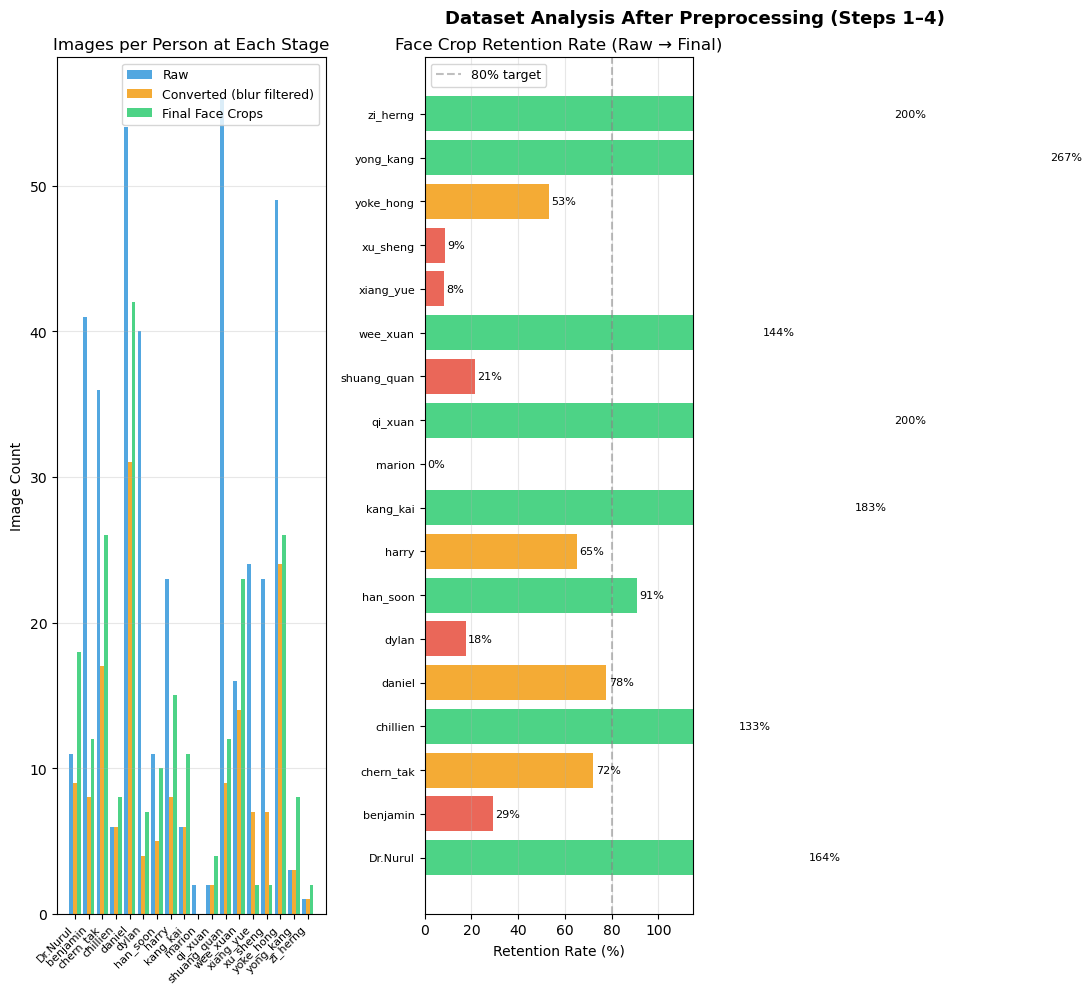


📋 SUMMARY:
  People:              18
  Raw images:          404
  Dropped (blurry):    243  (60.1%)
  After conversion:    161  (39.9%)
  Final face crops:    228  (56.4% overall retention)

  ⚠️ Moderate retention. Some images had undetectable faces or were blurry.


In [54]:
def analyze_preprocessed_dataset():
    """
    Compare per-person image counts at each pipeline stage:
    Raw → Converted (blur filtered) → Final Processed (face crops).
    Shows retention rates and flags people with low retention.
    """
    print("📊 DATASET ANALYSIS AFTER PREPROCESSING")
    print("=" * 60)

    def count_per_person(folder, extensions=None):
        if extensions is None:
            extensions = {'.jpg', '.jpeg', '.png'}
        result = {}
        if not os.path.exists(folder):
            return result
        for person in sorted(os.listdir(folder)):
            person_path = os.path.join(folder, person)
            if os.path.isdir(person_path):
                files = [f for f in os.listdir(person_path)
                         if Path(f).suffix.lower() in extensions]
                result[person] = len(files)
        return result

    raw_counts   = count_per_person(RAW_FOLDER, {'.jpg', '.jpeg', '.png', '.heic'})
    conv_counts  = count_per_person(CONVERTED_FOLDER)
    final_counts = count_per_person(FINAL_PROCESSED_FOLDER)

    all_people = sorted(set(raw_counts) | set(conv_counts) | set(final_counts))

    if not all_people:
        print("❌ No data found. Run the pipeline (Steps 1–4) first.")
        return

    # --- Table ---
    print(f"\n  {'Person':<16} {'Raw':>5} {'Converted':>10} {'Final':>7} {'Retention':>10}")
    print("  " + "─" * 54)

    for person in all_people:
        raw   = raw_counts.get(person, 0)
        conv  = conv_counts.get(person, 0)
        final = final_counts.get(person, 0)
        ret   = f"{final / raw * 100:.0f}%" if raw > 0 else "—"
        flag  = (" ✅" if final / max(raw, 1) >= 0.8
                 else (" ⚠️" if final / max(raw, 1) >= 0.5 else " ❌"))
        print(f"  {person:<16} {raw:>5} {conv:>10} {final:>7} {ret:>10}{flag}")

    print("  " + "─" * 54)
    total_raw   = sum(raw_counts.values())
    total_conv  = sum(conv_counts.values())
    total_final = sum(final_counts.values())
    total_ret   = f"{total_final / total_raw * 100:.0f}%" if total_raw > 0 else "—"
    print(f"  {'TOTAL':<16} {total_raw:>5} {total_conv:>10} {total_final:>7} {total_ret:>10}")

    # --- Visualization ---
    fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(all_people) * 0.45 + 2)))
    fig.suptitle("Dataset Analysis After Preprocessing (Steps 1–4)",
                 fontsize=13, fontweight='bold')

    short = [p[:12] for p in all_people]
    x = range(len(all_people))
    w = 0.28

    # Chart 1: grouped bars — raw / converted / final per person
    axes[0].bar([i - w for i in x], [raw_counts.get(p, 0) for p in all_people],
                width=w, label='Raw', color='#3498db', alpha=0.85)
    axes[0].bar(list(x), [conv_counts.get(p, 0) for p in all_people],
                width=w, label='Converted (blur filtered)', color='#f39c12', alpha=0.85)
    axes[0].bar([i + w for i in x], [final_counts.get(p, 0) for p in all_people],
                width=w, label='Final Face Crops', color='#2ecc71', alpha=0.85)
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(short, rotation=45, ha='right', fontsize=8)
    axes[0].set_ylabel("Image Count")
    axes[0].set_title("Images per Person at Each Stage")
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3, axis='y')

    # Chart 2: retention rate (raw → final face crops)
    retention  = [(final_counts.get(p, 0) / max(raw_counts.get(p, 1), 1)) * 100
                  for p in all_people]
    bar_colors = ['#2ecc71' if r >= 80 else ('#f39c12' if r >= 50 else '#e74c3c')
                  for r in retention]
    axes[1].barh(list(x), retention, color=bar_colors, alpha=0.85)
    axes[1].set_yticks(list(x))
    axes[1].set_yticklabels(short, fontsize=8)
    axes[1].axvline(x=80, color='gray', linestyle='--', alpha=0.5, label='80% target')
    axes[1].set_xlabel("Retention Rate (%)")
    axes[1].set_title("Face Crop Retention Rate (Raw → Final)")
    axes[1].set_xlim(0, 115)
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3, axis='x')
    for i, r in enumerate(retention):
        axes[1].text(r + 1, i, f'{r:.0f}%', va='center', fontsize=8)

    plt.tight_layout()
    plt.show()

    # --- Summary ---
    print(f"\n📋 SUMMARY:")
    print(f"  People:              {len(all_people)}")
    print(f"  Raw images:          {total_raw}")
    if total_raw > 0:
        blurry_dropped = total_raw - total_conv
        print(f"  Dropped (blurry):    {blurry_dropped}  ({blurry_dropped / total_raw * 100:.1f}%)")
        print(f"  After conversion:    {total_conv}  ({total_conv / total_raw * 100:.1f}%)")
        print(f"  Final face crops:    {total_final}  ({total_final / total_raw * 100:.1f}% overall retention)")

        overall_ret = total_final / total_raw
        if overall_ret < 0.5:
            print(f"\n  ❌ Low retention (<50%). Check: lighting, face angles, or lower BLUR_THRESHOLD.")
        elif overall_ret < 0.8:
            print(f"\n  ⚠️ Moderate retention. Some images had undetectable faces or were blurry.")
        else:
            print(f"\n  ✅ Good retention rate. Pipeline is working well.")

# Analyze dataset after completing Steps 1–4
analyze_preprocessed_dataset()


# 📊 Processing Summary & Statistics

View the complete processing statistics:

In [55]:
def generate_processing_summary():
    """Generate comprehensive processing summary across all pipeline stages."""
    
    print("📊 COMPLETE PROCESSING SUMMARY")
    print("=" * 60)
    
    # Helper: count images in a folder (recursively through person subfolders)
    def count_folder_images(folder_path):
        if not os.path.exists(folder_path):
            return 0, 0  # (people_count, image_count)
        person_dirs = [d for d in os.listdir(folder_path) 
                      if os.path.isdir(os.path.join(folder_path, d))]
        total_files = 0
        for person in person_dirs:
            person_path = os.path.join(folder_path, person)
            files = [f for f in os.listdir(person_path) 
                    if Path(f).suffix.lower() in {'.jpg', '.jpeg', '.png'}]
            total_files += len(files)
        return len(person_dirs), total_files
    
    # Original raw dataset
    raw_people, raw_total = count_folder_images(RAW_FOLDER)
    print(f"\n📷 RAW DATASET:")
    print(f"  • People: {raw_people}")
    print(f"  • Images: {raw_total}")
    if raw_people > 0:
        print(f"  • Avg per person: {raw_total / raw_people:.1f}")
    
    # Processing stages
    stages = [
        ("🔄 CONVERTED",       CONVERTED_FOLDER,       None),
        ("🔄 AUGMENTED",       AUGMENTED_FOLDER,        "augmentation"),
        ("🔄 PREPROCESSED",    PREPROCESSED_FOLDER,     None),
        ("👤 FACES DETECTED",  FACES_DETECTED_FOLDER,   "detection"),
        ("⚡ FINAL PROCESSED", FINAL_PROCESSED_FOLDER,  None),
    ]
    
    for stage_name, folder_path, stage_type in stages:
        people_count, file_count = count_folder_images(folder_path)
        
        if os.path.exists(folder_path):
            print(f"\n{stage_name}:")
            print(f"  • People: {people_count}")
            print(f"  • Images: {file_count}")
            
            if stage_type == "augmentation" and raw_total > 0 and file_count > 0:
                multiplication = file_count / raw_total
                print(f"  • Dataset multiplication: {multiplication:.1f}x")
                if people_count > 0:
                    print(f"  • Avg per person: {file_count / people_count:.1f}")
            
            if stage_type == "detection" and raw_total > 0 and file_count > 0:
                print(f"  • Faces per original: {file_count / raw_total:.1f}")
        else:
            print(f"\n❌ {stage_name}: Folder not created yet")
    
    print(f"\n{'=' * 60}")
    print(f"✨ Summary complete!")

generate_processing_summary()

📊 COMPLETE PROCESSING SUMMARY

📷 RAW DATASET:
  • People: 18
  • Images: 121
  • Avg per person: 6.7

🔄 CONVERTED:
  • People: 18
  • Images: 161

🔄 AUGMENTED:
  • People: 18
  • Images: 3200
  • Dataset multiplication: 26.4x
  • Avg per person: 177.8

🔄 PREPROCESSED:
  • People: 18
  • Images: 322

👤 FACES DETECTED:
  • People: 18
  • Images: 228
  • Faces per original: 1.9

⚡ FINAL PROCESSED:
  • People: 18
  • Images: 228

✨ Summary complete!


# 📹 Step 5: Live Face Detection (Updated)

Enhanced real-time face detection with the new pipeline:

In [56]:
def start_live_face_detection():
    """Start live face detection with pipeline integration"""
    
    print("📹 STARTING LIVE FACE DETECTION")
    print("Controls:")
    print("  • Press 'q' to quit")
    print("  • Press 's' to save detected face")
    print("  • Press 'p' to toggle preprocessing display")
    
    # Setup
    video_capture = cv2.VideoCapture(0)
    if not video_capture.isOpened():
        print("❌ Could not open camera!")
        return
    
    # Create output folder for detected faces
    detected_faces_folder = os.path.join(DATA_FOLDER, "detectedFaces")
    os.makedirs(detected_faces_folder, exist_ok=True)
    
    # Settings
    last_save = 0
    save_delay = 2
    show_preprocessing = False
    
    # CLAHE for preprocessing
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    
    print("🎥 Camera active. Press 'q' to stop.")
    
    while True:
        ret, frame = video_capture.read()
        if not ret:
            break
        
        # Create display frame
        display_frame = frame.copy()
        
        # Preprocessing for better detection
        small_frame = cv2.resize(frame, (0, 0), fx=0.25, fy=0.25)
        gray_small = cv2.cvtColor(small_frame, cv2.COLOR_BGR2GRAY)
        equ_small = clahe.apply(gray_small)
        
        # Face detection using our pipeline
        face_locations = face_recognition.face_locations(equ_small, model="hog")
        
        for face_loc in face_locations:
            # Scale coordinates back to original frame size (x4)
            top, right, bottom, left = [v * 4 for v in face_loc]
            
            # Apply padding
            h, w = bottom - top, right - left
            pad_h, pad_w = int(h * FACE_PADDING_RATIO), int(w * FACE_PADDING_RATIO)
            
            # Boundary handling
            img_h, img_w = frame.shape[:2]
            p_top = max(0, top - pad_h)
            p_bottom = min(img_h, bottom + pad_h)
            p_left = max(0, left - pad_w)
            p_right = min(img_w, right + pad_w)
            
            # Save face if enough time has passed
            if time.time() - last_save > save_delay:
                face_crop = frame[p_top:p_bottom, p_left:p_right]
                
                # Resize to standard size
                if face_crop.size > 0:
                    face_resized = cv2.resize(face_crop, OUTPUT_SIZE, interpolation=cv2.INTER_AREA)
                    
                    timestamp = time.strftime('%Y%m%d_%H%M%S')
                    filename = f"live_face_{timestamp}.jpg"
                    save_path = os.path.join(detected_faces_folder, filename)
                    
                    cv2.imwrite(save_path, face_resized)
                    print(f"💾 Saved: {filename}")
                    last_save = time.time()
            
            # Draw detection rectangles
            cv2.rectangle(display_frame, (left, top), (right, bottom), (0, 255, 0), 2)  # Face
            cv2.rectangle(display_frame, (p_left, p_top), (p_right, p_bottom), (255, 0, 0), 1)  # Padding
            
            # Add label
            cv2.putText(display_frame, f"Face {OUTPUT_SIZE[0]}x{OUTPUT_SIZE[1]}", 
                       (left, top - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 1)
        
        # Add instructions
        cv2.putText(display_frame, "Press 'q' to quit, 's' to save, 'p' for preprocessing", 
                   (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)
        
        cv2.putText(display_frame, f"Faces: {len(face_locations)} | Saved to: detectedFaces/", 
                   (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        
        # Show preprocessing if enabled
        if show_preprocessing:
            # Show preprocessing steps side by side
            gray_display = cv2.cvtColor(cv2.resize(equ_small, (frame.shape[1]//4, frame.shape[0]//4)), cv2.COLOR_GRAY2BGR)
            display_frame[10:10+gray_display.shape[0], -gray_display.shape[1]-10:-10] = gray_display
            cv2.putText(display_frame, "Preprocessing", 
                       (display_frame.shape[1]-gray_display.shape[1]-10, gray_display.shape[0]+25), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 255), 1)
        
        cv2.imshow('Attendance System - Enhanced Face Detection', display_frame)
        
        # Handle key presses
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break
        elif key == ord('s'):
            print("Manual save triggered!")
            last_save = 0  # Force save on next detection
        elif key == ord('p'):
            show_preprocessing = not show_preprocessing
            print(f"Preprocessing display: {'ON' if show_preprocessing else 'OFF'}")
    
    video_capture.release()
    cv2.destroyAllWindows()
    print("📹 Live detection stopped")

print("📹 Live face detection ready!")
print("Run the cell below to start the camera...")

📹 Live face detection ready!
Run the cell below to start the camera...


In [57]:
# Uncomment the line below to start live face detection
# start_live_face_detection()

print("💡 Uncomment the line above to start live face detection")
print("⚠️  Make sure you have a working camera connected")

💡 Uncomment the line above to start live face detection
⚠️  Make sure you have a working camera connected


# 🛠️ Utility Functions

Additional helper functions for your workflow:

In [58]:
def preview_random_augmentations(person_name, num_examples=1):
    """Show random augmentation examples for a person using the new DataAugmentor."""
    
    person_path = os.path.join(AUGMENTED_FOLDER, person_name)
    if not os.path.exists(person_path):
        # Fallback to raw folder
        person_path = os.path.join(RAW_FOLDER, person_name)
        if not os.path.exists(person_path):
            print(f"❌ No images found for {person_name}")
            return
    
    image_files = [f for f in os.listdir(person_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not image_files:
        print(f"❌ No image files found for {person_name}")
        return
    
    # Take random sample
    sample_files = random.sample(image_files, min(num_examples, len(image_files)))
    
    for img_file in sample_files:
        img_path = os.path.join(person_path, img_file)
        image = cv2.imread(img_path)
        
        if image is None:
            continue
        
        # Generate augmentations using the DataAugmentor
        pipeline_names = list(augmentor.pipelines.keys())
        aug_images = [augmentor.augment_single_image(image, p) for p in pipeline_names]
        
        # Create visualization
        all_images = [image] + aug_images
        titles = ["Original"] + pipeline_names
        
        cols = len(all_images)
        fig, axes = plt.subplots(1, cols, figsize=(3 * cols, 3.5))
        for i, (img, title) in enumerate(zip(all_images, titles)):
            axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            axes[i].set_title(title, fontsize=10)
            axes[i].axis('off')
        
        plt.suptitle(f"Augmentation Examples - {person_name} - {img_file}", fontsize=12)
        plt.tight_layout()
        plt.show()

def clean_processing_folders():
    """Clean all processing output folders (keeps raw/)"""
    import shutil
    
    folders_to_clean = [
        CONVERTED_FOLDER, PREPROCESSED_FOLDER, AUGMENTED_FOLDER,
        FACES_DETECTED_FOLDER, FINAL_PROCESSED_FOLDER, PREVIEW_FOLDER
    ]
    
    print("🧹 CLEANING PROCESSING FOLDERS")
    
    for folder in folders_to_clean:
        if os.path.exists(folder):
            try:
                shutil.rmtree(folder)
                print(f"✅ Cleaned: {os.path.relpath(folder, '..')}")
            except Exception as e:
                print(f"❌ Error cleaning {folder}: {e}")
        else:
            print(f"⚠️ Not found: {os.path.relpath(folder, '..')}")
    
    print("🧹 Cleaning complete!")

def export_face_encodings(output_path="face_encodings.npz"):
    """Export face encodings for all final processed faces"""
    
    source_folder = FINAL_PROCESSED_FOLDER
    if not os.path.exists(source_folder):
        source_folder = FACES_DETECTED_FOLDER
        if not os.path.exists(source_folder):
            print("❌ No processed faces found! Run the pipeline first.")
            return
    
    print(f"🔍 Extracting face encodings from {os.path.relpath(source_folder, '..')}...")
    
    encodings = []
    labels = []
    
    person_folders = [f for f in os.listdir(source_folder) 
                     if os.path.isdir(os.path.join(source_folder, f))]
    
    for person in person_folders:
        person_path = os.path.join(source_folder, person)
        face_files = [f for f in os.listdir(person_path) if f.lower().endswith('.jpg')]
        
        print(f"  👤 {person}: {len(face_files)} faces")
        
        for face_file in face_files:
            face_path = os.path.join(person_path, face_file)
            image = cv2.imread(face_path)
            
            if image is None:
                continue
            
            # Convert to RGB
            rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            # Get encoding
            face_encs = face_recognition.face_encodings(rgb_image)
            
            if face_encs:
                encodings.append(face_encs[0])
                labels.append(person)
    
    if encodings:
        np.savez(output_path, encodings=encodings, labels=labels)
        print(f"💾 Saved {len(encodings)} face encodings to {output_path}")
    else:
        print("❌ No face encodings found!")

print("🛠️ Utility functions loaded!")
print("Available functions:")
print("  • preview_random_augmentations(person_name) - Show augmentation examples") 
print("  • clean_processing_folders() - Clean all processed data")
print("  • export_face_encodings() - Export encodings for training")

🛠️ Utility functions loaded!
Available functions:
  • preview_random_augmentations(person_name) - Show augmentation examples
  • clean_processing_folders() - Clean all processed data
  • export_face_encodings() - Export encodings for training


# 🎯 Quick Actions

Run these cells for common tasks:

In [59]:
# QUICK ACTION: Run complete pipeline
def run_complete_pipeline():
    """Run the complete processing pipeline end-to-end."""
    print("🚀 RUNNING COMPLETE PIPELINE")
    print("=" * 50)
    
    # Step 1: Convert images (HEIC → JPG, standardize)
    print("\n1️⃣ Converting images...")
    convert_all_images()
    
    # Step 2: Grayscale + CLAHE preprocessing
    print("\n2️⃣ Preprocessing (grayscale + CLAHE)...")
    run_preprocessing()
    
    # Step 3: Face detection & ROI extraction
    print("\n3️⃣ Extracting face ROIs...")
    extract_faces_from_preprocessed()
    
    # Step 4: Post-process extracted faces
    print("\n4️⃣ Post-processing faces...")
    post_process_extracted_faces()
    
    # Step 5a: Raw image augmentation (preview & illumination evaluation)
    print("\n5️⃣a Augmenting raw images (for evaluation)...")
    run_augmentation()
    
    # Step 5b: Augment face crops for training
    print("\n5️⃣b Augmenting face crops for training...")
    augment_face_crops()
    
    # Step 6: Prepare training data
    print("\n6️⃣ Preparing training dataset...")
    global training_data
    training_data = prepare_training_data()
    
    # Step 7: Train LBPH model
    print("\n7️⃣ Training LBPH model...")
    global lbph_result
    lbph_result = train_lbph_model(training_data)
    
    # Step 8: Generate summary
    print("\n8️⃣ Generating summary...")
    generate_processing_summary()
    
    print("\n🎉 PIPELINE COMPLETE!")
    print("📊 Run plot_evaluation(lbph_result) to see detailed evaluation")
    print("📊 Run compare_augmentation_impact() to compare with/without augmentation")

# Uncomment the line below to run the complete pipeline
# run_complete_pipeline()

print("💡 Uncomment the line above to run the complete pipeline")
print("⚠️  This will process all images in your dataset")


💡 Uncomment the line above to run the complete pipeline
⚠️  This will process all images in your dataset


In [60]:
# QUICK ACTION: Clean old pipeline folders
def clean_old_pipeline_folders():
    """Clean remnants from the old augmentation pipeline"""
    import shutil
    
    old_folders = [
        os.path.join(DATA_FOLDER, "processed"),    # Old face extraction folder
        os.path.join(DATA_FOLDER, "detectedFaces"), # Old detection folder
    ]
    
    print("🧹 CLEANING OLD PIPELINE FOLDERS")
    print("=" * 40)
    
    for folder in old_folders:
        folder_name = os.path.basename(folder)
        if os.path.exists(folder):
            try:
                shutil.rmtree(folder)
                print(f"✅ Deleted old folder: {folder_name}/")
            except Exception as e:
                print(f"❌ Error deleting {folder_name}/: {e}")
        else:
            print(f"⚠️ Not found: {folder_name}/")
    
    print("\n🧹 Cleanup complete!")

# QUICK ACTION: Show current folder status  
def show_folder_status():
    """Show status of all data folders"""
    print("📁 CURRENT FOLDER STATUS")
    print("=" * 50)
    
    # Current workflow folders
    current_folders = [
        ("raw",              RAW_FOLDER,              "📷 Original images (input)"),
        ("augmented",        AUGMENTED_FOLDER,         "🔄 Augmented images (Member 3)"),
        ("converted",        CONVERTED_FOLDER,         "🔄 Standardized JPGs"),
        ("preprocessed",     PREPROCESSED_FOLDER,      "🔄 Grayscale + CLAHE"),
        ("faces_detected",   FACES_DETECTED_FOLDER,    "👤 Extracted face ROIs"),
        ("final_processed",  FINAL_PROCESSED_FOLDER,   "⚡ Final processed faces"),
        ("preview",          PREVIEW_FOLDER,            "👁️ Preview & evaluation"),
        ("models",           MODELS_FOLDER,             "🧠 Trained models"),
    ]
    
    print("\n📂 ALL PIPELINE FOLDERS:")
    for name, path, description in current_folders:
        exists = "✅" if os.path.exists(path) else "❌"
        files_count = 0
        if os.path.exists(path):
            try:
                # Count files recursively (including subfolders)
                for root, dirs, files in os.walk(path):
                    files_count += len([f for f in files if not f.startswith('.')])
            except:
                files_count = 0
        print(f"  {exists} {name:17} {files_count:5d} files  {description}")
    
    # Check for old pipeline folders that can be cleaned
    old_folders = ["processed", "detectedFaces"]
    old_found = []
    for name in old_folders:
        path = os.path.join(DATA_FOLDER, name)
        if os.path.exists(path):
            old_found.append(name)
    
    if old_found:
        print(f"\n⚠️ Old pipeline folders found: {', '.join(old_found)}")
        print("   Run clean_old_pipeline_folders() to remove them.")

# Show current status
show_folder_status()

📁 CURRENT FOLDER STATUS

📂 ALL PIPELINE FOLDERS:
  ✅ raw                 408 files  📷 Original images (input)
  ✅ augmented          3200 files  🔄 Augmented images (Member 3)
  ✅ converted           161 files  🔄 Standardized JPGs
  ✅ preprocessed        322 files  🔄 Grayscale + CLAHE
  ✅ faces_detected      228 files  👤 Extracted face ROIs
  ✅ final_processed     228 files  ⚡ Final processed faces
  ✅ preview               5 files  👁️ Preview & evaluation
  ✅ models                4 files  🧠 Trained models


# ✅ Pipeline Complete!

Your image processing pipeline is now ready! Here's what you have:

## 📊 Pipeline Summary
| Step | Description | Input → Output | Owner |
|------|-------------|----------------|-------|
| 1 | **Image Conversion** | `raw/` → `converted/` (HEIC→JPG, standardize) | Member 1 |
| 2 | **Grayscale & CLAHE** | `converted/` → `preprocessed/` | Member 1 |
| 3 | **Face Detection & ROI** | `preprocessed/` → `faces_detected/` (128×128) | Member 1 |
| 4 | **Post-Processing** | `faces_detected/` → `final_processed/` (CLAHE on crops) | Member 1 |
| 5a | **Raw Image Augmentation** | `raw/` → `augmented/` (evaluation) | Member 3 |
| 5b | **Face Crop Augmentation** | `final_processed/` → `augmented/` (~100/person) | Member 3 |
| 6 | **Training Data Prep** | `augmented/` → NumPy arrays (80/20 split) | Member 3 |
| 7 | **LBPH Training** | Training arrays → `models/lbph_model.yml` | Member 3 |

## 📊 Evaluation Outputs
| Evaluation | Output |
|-----------|--------|
| Augmentation Preview | `preview/augmentation_samples/` |
| Illumination Robustness | `preview/evaluation_results/illumination_robustness_evaluation.png` |
| LBPH Confusion Matrix | `preview/evaluation_results/lbph_evaluation.png` |
| With vs Without Aug | `preview/evaluation_results/augmentation_impact_comparison.png` |

## 🚀 Next Steps
1. Run the complete pipeline using the quick action cell above
2. Review LBPH evaluation results in `data/preview/evaluation_results/`
3. Compare augmentation impact with `compare_augmentation_impact()`
4. Integrate trained model (`models/lbph_model.yml`) into the attendance application
5. Implement live face recognition using the trained LBPH model

## 💡 Tips
- Each person's ~16-20 face crops → ~100 augmented training images
- The pipeline preserves original images while creating organized copies
- LBPH model is saved to `models/` with a `label_map.txt` for person lookup
- Run `compare_augmentation_impact()` to see the value of augmentation quantitatively

Your facial recognition attendance system is now ready! 🎉


In [3]:
analyze_dataset()

NameError: name 'analyze_dataset' is not defined